In [38]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,       # Shows True/False Positives and Negatives
    roc_curve,              # Calculates ROC curve points
    roc_auc_score,          # Calculates AUC score
    classification_report,  # Full precision recall F1 report
    f1_score,               # F1 score for Dead class
    accuracy_score          # Overall accuracy
)

import os

os.makedirs("../outputs/figures", exist_ok=True)

# Load Logistic Regression model
lr_model = joblib.load('../outputs/models/logistic_regression.pkl')
print("=== LOGISTICS REGRESSION MODEL LOADED ===")

# Load the scaler - needed for Logistic Regression predictions
scaler = joblib.load('../outputs/models/scaler.pkl')
print("=== SCALER LOADED ===")

# Load Random Forest model
rf_model = joblib.load('../outputs/models/random_forest.pkl')
print("=== RANDOM FOREST MODEL LOADED ===")

# Load XGBoost model
xgb_model = joblib.load("../outputs/models/xgboost.pkl")
print("=== XGBOOST MODEL LOADED ===")

# Load test data - real patients only
x_test = pd.read_csv("../outputs/processed_data/x_test.csv")
y_test = pd.read_csv("../outputs/processed_data/y_test.csv").squeeze()
print()
print("=== TEST DATA LOADED ===")
print("Test set size:")
print(x_test.shape)

# Scale test data for Logistic Regression. We must use the same scaler fitted during training
x_test_scaled = scaler.transform(x_test)
print()
print("=== TEST DATA SCALED FOR LOGISTIC REGRESSION ===")

# Generate predictions from all three models

# Logistic Regression uses scaled data
lr_predictions = lr_model.predict(x_test_scaled)
lr_probabilities = lr_model.predict_proba(x_test_scaled)[:, 1]

# Random Forest and XGBoost use unscaled data
rf_predictions = rf_model.predict(x_test)
rf_probabilities = rf_model.predict_proba(x_test)[:, 1]

xgb_predictions = xgb_model.predict(x_test)
xgb_probabilities = xgb_model.predict_proba(x_test)[:, 1]

print()
print("=== ALL PREDICTIONS GENERATED ===")
print("Ready to create evaluation visualisations")

=== LOGISTICS REGRESSION MODEL LOADED ===
=== SCALER LOADED ===
=== RANDOM FOREST MODEL LOADED ===
=== XGBOOST MODEL LOADED ===

=== TEST DATA LOADED ===
Test set size:
(805, 17)

=== TEST DATA SCALED FOR LOGISTIC REGRESSION ===

=== ALL PREDICTIONS GENERATED ===
Ready to create evaluation visualisations


=== CONFUSION MATRICES SAVED ===
Saved to outputs/figures/confusion_matrices.png


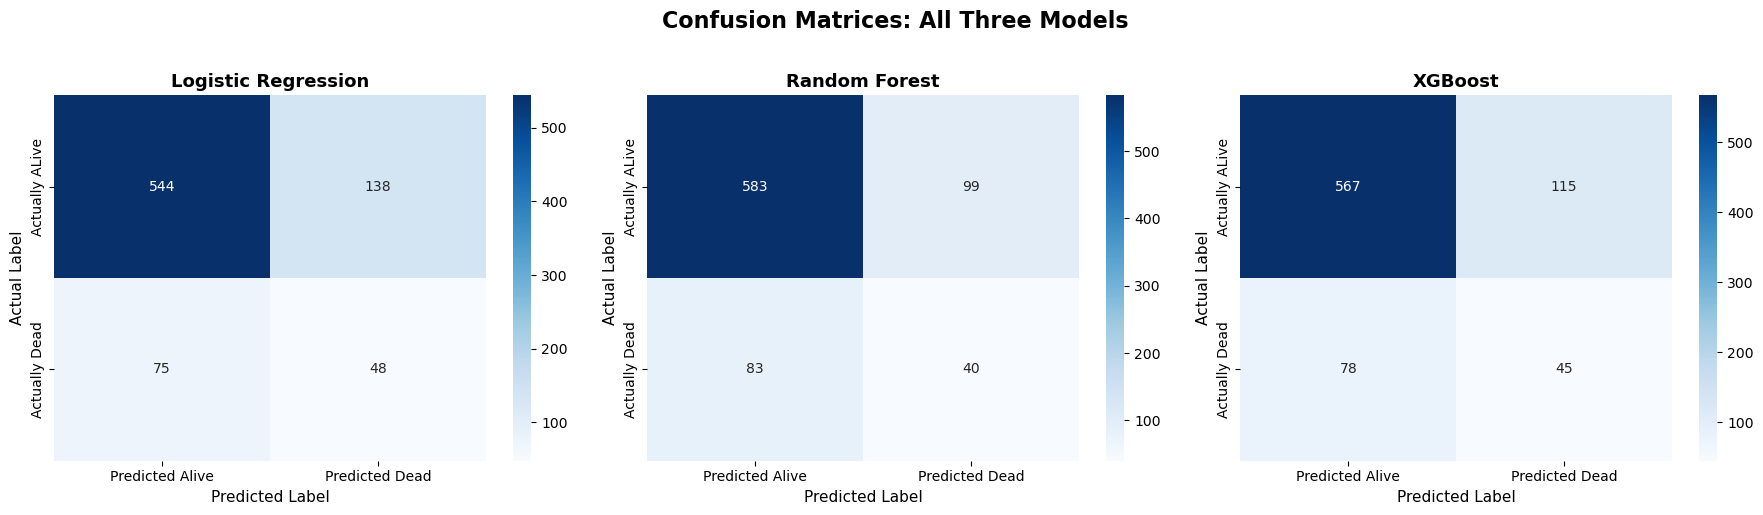

In [39]:
# ============================================================
# CONFUSION MATRICES FOR ALL THREE MODELS
# ============================================================

# Create a figure with three subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Set the main title for the entire figure
fig.suptitle("Confusion Matrices: All Three Models",
            fontsize=16, fontweight="bold", y=1.02)

# Define model names, predictions and axis for each model
models = [
    ("Logistic Regression", lr_predictions),
    ("Random Forest", rf_predictions),
    ("XGBoost", xgb_predictions)
]

# Loop through each model and create one confusion matrix per model
for idx, (model_name, predictions) in enumerate(models):
    
    # Calculate the confusion matrix
    # Returns a 2x2 array of counts
    cm = confusion_matrix(y_test, predictions)

    # Create a heatmap from the confusion matrix
    sns.heatmap(
            cm,
            annot=True,                                         # Show numbers inside cells
            fmt="d",                                            # Format as integers
            cmap="Blues",                                       # Blue colour scheme                                  
            ax=axes[idx],                                       # Which subplot to use
            xticklabels=["Predicted Alive", "Predicted Dead"],  # X axis labels
            yticklabels=["Actually ALive", "Actually Dead"]     # Y axis labels
    )

    # Set title and axis labels for each subplot
    axes[idx].set_title(model_name, fontsize=13, fontweight="bold")
    axes[idx].set_ylabel("Actual Label", fontsize=11)
    axes[idx].set_xlabel("Predicted Label", fontsize=11)

# Adjust spacing between subplots so nothing overlaps
plt.tight_layout()

# Save the figure to outputs/figures folder
plt.savefig("../outputs/figures/confusion_matrices.png",
            dpi=150,              # High resolution
            bbox_inches="tight"  # Remove extra whitespace around figure
            )

print("=== CONFUSION MATRICES SAVED ===")
print("Saved to outputs/figures/confusion_matrices.png")

# Display the figure in the notebook
plt.show()

=== ROC CURVES SAVED ===
Saved to outputs/figures/roc_curves.png


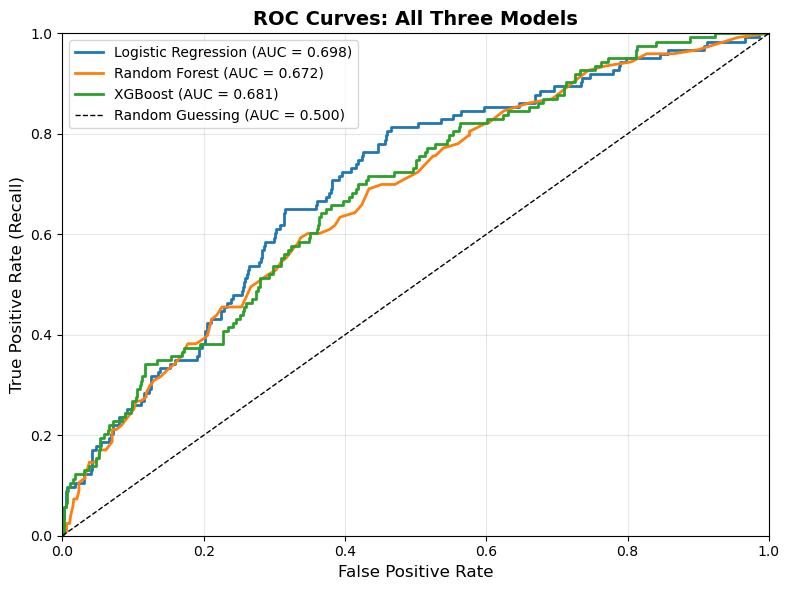

In [40]:
# ============================================================
# ROC CURVES FOR ALL THREE MODELS
# ============================================================

# Create a single figure for all three ROC curves
fig, ax = plt.subplots(figsize=(8, 6))

# Define models with their probabilities and display names
# We use probabilities here not predictions, ROC curve needs probability scores
models_roc = [
    ('Logistic Regression', lr_probabilities),
    ('Random Forest', rf_probabilities),
    ('XGBoost', xgb_probabilities)
]

# Loop through each model and plot its ROC curve
for model_name, probabilities in models_roc:

    # roc_curve calculates the true positive rate and false positive rate
    # at every possible probability threshold
    # fpr = false positive rate (x axis)
    # tpr = true positive rate / recall (y axis)
    fpr, tpr, thresholds = roc_curve(y_test, probabilities)

    # Calculate AUC score for this model
    auc_score = roc_auc_score(y_test, probabilities)

    # Plot the ROC curve for this model
    # label shows the model name and AUC score in the legend
    ax.plot(fpr, tpr, linewidth=2,
            label=f'{model_name} (AUC = {auc_score:.3f})')

# Plot the diagonal line representing random guessing
# A model that guesses randomly would follow this line
# AUC of 0.5, no better than flipping a coin
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guessing (AUC = 0.500)')

# Set axis labels
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)

# Set title
ax.set_title('ROC Curves: All Three Models', fontsize=14, fontweight='bold')

# Add legend to identify each curve
ax.legend(fontsize=10)

# Add grid for easier reading
ax.grid(True, alpha=0.3)

# Set axis limits
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig('../outputs/figures/roc_curves.png',
            dpi=150,
            bbox_inches='tight')

print("=== ROC CURVES SAVED ===")
print("Saved to outputs/figures/roc_curves.png")

plt.show()

C:\Users\ravin\AppData\Local\Temp\ipykernel_43332\3065030859.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(models_names, rotation=15, ha='right', fontsize=9)
C:\Users\ravin\AppData\Local\Temp\ipykernel_43332\3065030859.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(models_names, rotation=15, ha='right', fontsize=9)
C:\Users\ravin\AppData\Local\Temp\ipykernel_43332\3065030859.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(models_names, rotation=15, ha='right', fontsize=9)
C:\Users\ravin\AppData\Local\Temp\ipykernel_43332\3065030859.py:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a

=== MODEL COMPARISON CHART SAVED ===
Saved to outputs/figures/model_comparison.png


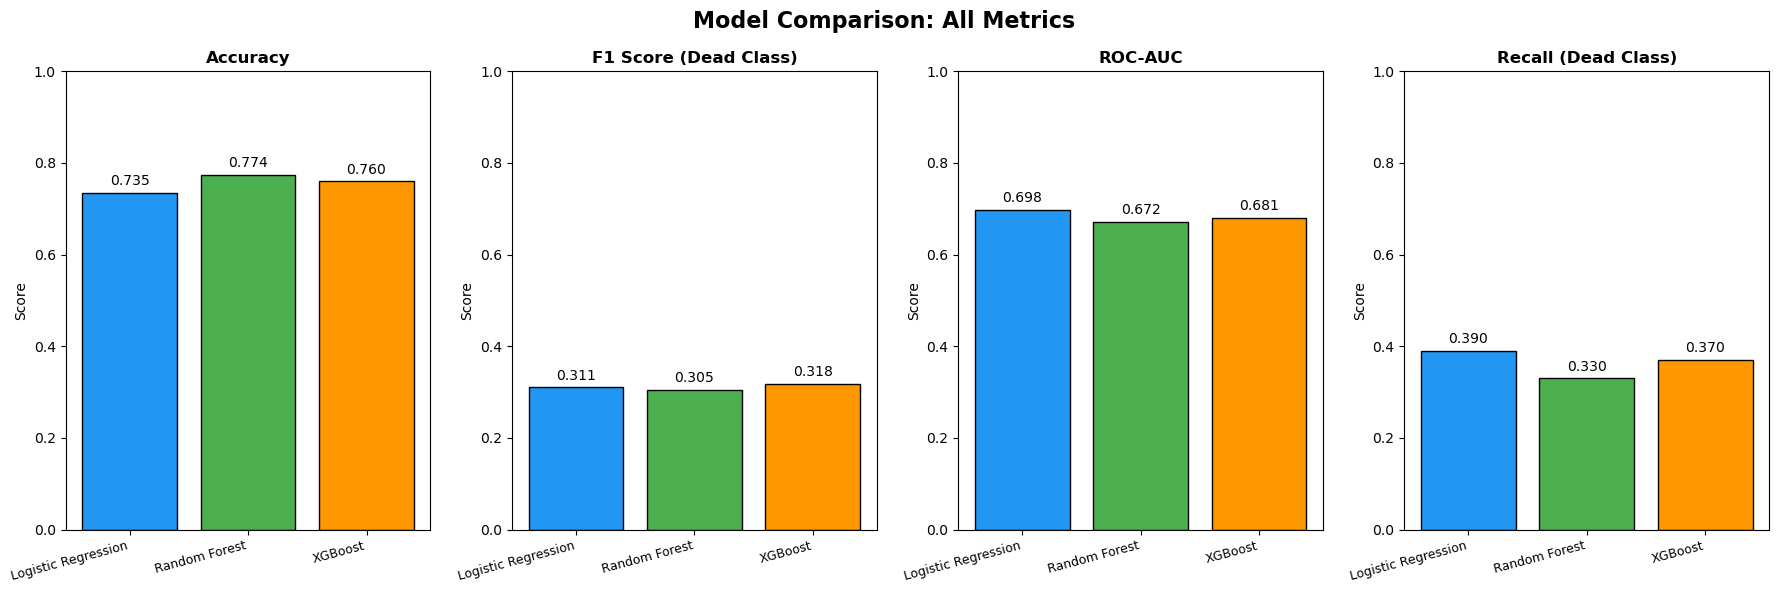

In [41]:
# ============================================================
# MODEL COMPARISON BAR CHART
# ============================================================

# Define the metrics and scores for each model
# These are the corrected values including fixed ROC-AUC for Logistic Regression
models_names = ['Logistic Regression', 'Random Forest', 'XGBoost']

# Accuracy scores for each model
accuracy_scores = [0.7354, 0.7739, 0.7602]

# F1 scores for Dead class for each model
f1_scores = [0.3107, 0.3053, 0.3180]

# ROC-AUC scores for each model
roc_auc_scores = [0.698, 0.672, 0.681]

# Recall scores for Dead class for each model
recall_scores = [0.39, 0.33, 0.37]

# Set up the figure with 4 subplots, one per metric
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

# Set main title
fig.suptitle('Model Comparison: All Metrics', 
             fontsize=16, fontweight='bold')

# Define colours for each bar, one colour per model
colours = ['#2196F3', '#4CAF50', '#FF9800']

# ============================================================
# Plot 1: Accuracy
# ============================================================

bars = axes[0].bar(models_names, accuracy_scores, color=colours, edgecolor='black')
axes[0].set_title('Accuracy', fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].set_ylabel('Score')

# Add value labels on top of each bar
for bar, score in zip(bars, accuracy_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 0.01,
                 f'{score:.3f}', 
                 ha='center', va='bottom', fontsize=10)

# Rotate x axis labels so they do not overlap
axes[0].set_xticklabels(models_names, rotation=15, ha='right', fontsize=9)

# ============================================================
# Plot 2: F1 Score (Dead class)
# ============================================================

bars = axes[1].bar(models_names, f1_scores, color=colours, edgecolor='black')
axes[1].set_title('F1 Score (Dead Class)', fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].set_ylabel('Score')

for bar, score in zip(bars, f1_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{score:.3f}',
                 ha='center', va='bottom', fontsize=10)

axes[1].set_xticklabels(models_names, rotation=15, ha='right', fontsize=9)

# ============================================================
# Plot 3: ROC-AUC
# ============================================================

bars = axes[2].bar(models_names, roc_auc_scores, color=colours, edgecolor='black')
axes[2].set_title('ROC-AUC', fontweight='bold')
axes[2].set_ylim([0, 1])
axes[2].set_ylabel('Score')

for bar, score in zip(bars, roc_auc_scores):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{score:.3f}',
                 ha='center', va='bottom', fontsize=10)

axes[2].set_xticklabels(models_names, rotation=15, ha='right', fontsize=9)

# ============================================================
# Plot 4: Recall (Dead class)
# ============================================================

bars = axes[3].bar(models_names, recall_scores, color=colours, edgecolor='black')
axes[3].set_title('Recall (Dead Class)', fontweight='bold')
axes[3].set_ylim([0, 1])
axes[3].set_ylabel('Score')

for bar, score in zip(bars, recall_scores):
    axes[3].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{score:.3f}',
                 ha='center', va='bottom', fontsize=10)

axes[3].set_xticklabels(models_names, rotation=15, ha='right', fontsize=9)

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig('../outputs/figures/model_comparison.png',
            dpi=150,
            bbox_inches='tight')

print("=== MODEL COMPARISON CHART SAVED ===")
print("Saved to outputs/figures/model_comparison.png")

plt.show()

=== FEATURE IMPORTANCE SCORES ===
Higher score means the feature had more influence on predictions

                     Feature  Importance
                         Age    0.154226
                  Tumor Size    0.148760
      Regional Node Examined    0.140434
Progesterone Status_Positive    0.102212
      Regional Node Positive    0.088704
      Marital Status_Married    0.068016
    Estrogen Status_Positive    0.045810
       Marital Status_Single    0.043650
                   6th Stage    0.040860
                       Grade    0.037850
                  Race_White    0.031275
                  Race_Other    0.025679
                     T Stage    0.025541
                     N Stage    0.021027
      Marital Status_Widowed    0.018596
    Marital Status_Separated    0.003778
                     A Stage    0.003583

=== FEATURE IMPORTANCE CHART SAVED ===
Saved to outputs/figures/feature_importance.png


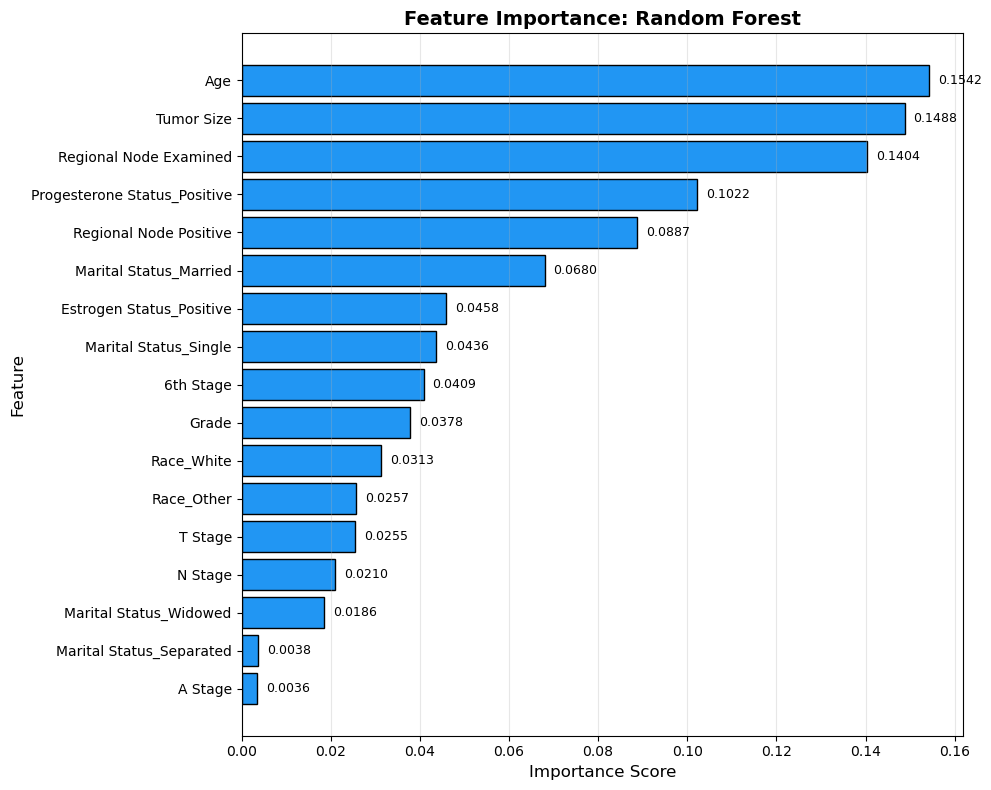

In [42]:
# ============================================================
# FEATURE IMPORTANCE: RANDOM FOREST
# ============================================================

# Random Forest has a built in feature_importances_ attribute
# This tells us how much each feature contributed to the model's decisions
# Higher value = more important feature
# We use Random Forest for feature importance because it is more stable
# and interpretable than XGBoost for this purpose

# Get feature importance scores from the trained Random Forest model
feature_importance = rf_model.feature_importances_

# Get the feature names from x_test columns
feature_names = x_test.columns.tolist()

# Create a DataFrame combining feature names and their importance scores
importance_df = pd.DataFrame({
    'Feature': feature_names,           # Column names from our dataset
    'Importance': feature_importance    # Importance score for each feature
})

# Sort by importance score from highest to lowest
importance_df = importance_df.sort_values('Importance', ascending=False)

print("=== FEATURE IMPORTANCE SCORES ===")
print("Higher score means the feature had more influence on predictions")
print()
print(importance_df.to_string(index=False))

# ============================================================
# PLOT FEATURE IMPORTANCE
# ============================================================

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Create horizontal bar chart
bars = ax.barh(
    importance_df['Feature'],      # Feature names on y axis
    importance_df['Importance'],   # Importance scores on x axis
    color='#2196F3',               # Blue colour
    edgecolor='black'              # Black border around each bar
)

# Add value labels at the end of each bar
for bar, importance in zip(bars, importance_df['Importance']):
    ax.text(
        bar.get_width() + 0.002,           # Position slightly right of bar end
        bar.get_y() + bar.get_height()/2,  # Vertically centred on bar
        f'{importance:.4f}',               # Show 4 decimal places
        va='center', fontsize=9
    )

# Set title and labels
ax.set_title('Feature Importance: Random Forest', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)

# Invert y axis so most important feature appears at top
ax.invert_yaxis()

# Add grid for easier reading
ax.grid(True, axis='x', alpha=0.3)

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig('../outputs/figures/feature_importance.png',
            dpi=150,
            bbox_inches='tight')

print()
print("=== FEATURE IMPORTANCE CHART SAVED ===")
print("Saved to outputs/figures/feature_importance.png")

plt.show()

In [43]:
# ============================================================
# SUBGROUP ANALYSIS
# ============================================================
# We split patients into subgroups and check model performance
# within each subgroup separately
# This tells us whether the model works equally well for all patients
# or whether it performs better for some groups than others

# We will analyse two subgroups:
# 1. Early stage (6th Stage 1-2) vs Late stage (6th Stage 3-5)
# 2. Estrogen Positive vs Estrogen Negative patients

# Use XGBoost predictions as it has the best F1 score
predictions = xgb_predictions

# ============================================================
# SUBGROUP 1: TUMOUR STAGE
# ============================================================

# Create a copy of x_test with y_test and predictions added
analysis_df = x_test.copy()
analysis_df['actual'] = y_test.values
analysis_df['predicted'] = predictions

# Early stage patients, 6th Stage values 1 or 2 (IIA or IIB)
early_stage = analysis_df[analysis_df['6th Stage'] <= 2]

# Late stage patients, 6th Stage values 3, 4, or 5 (IIIA, IIIB, IIIC)
late_stage = analysis_df[analysis_df['6th Stage'] >= 3]

print("=== SUBGROUP ANALYSIS: TUMOUR STAGE ===")
print()
print(f"Early Stage patients (Stage IIA-IIB): {len(early_stage)}")
print(f"Late Stage patients (Stage IIIA-IIIC): {len(late_stage)}")

print()
print("--- Early Stage Performance ---")
# Only evaluate if there are Dead patients in this subgroup
if early_stage['actual'].sum() > 0:
    print("F1 Score (Dead class):",
          round(f1_score(early_stage['actual'],
                        early_stage['predicted']), 4))
    print("Recall (Dead class):",
          round(early_stage[early_stage['actual']==1]['predicted'].mean(), 4))
else:
    print("No Dead patients in this subgroup")

print()
print("--- Late Stage Performance ---")
if late_stage['actual'].sum() > 0:
    print("F1 Score (Dead class):",
          round(f1_score(late_stage['actual'],
                        late_stage['predicted']), 4))
    print("Recall (Dead class):",
          round(late_stage[late_stage['actual']==1]['predicted'].mean(), 4))
else:
    print("No Dead patients in this subgroup")

# ============================================================
# SUBGROUP 2: ESTROGEN STATUS
# ============================================================

# Estrogen Positive patients, hormone driven cancer
estrogen_positive = analysis_df[analysis_df['Estrogen Status_Positive'] == 1]

# Estrogen Negative patients, non hormone driven cancer
estrogen_negative = analysis_df[analysis_df['Estrogen Status_Positive'] == 0]

print()
print("=== SUBGROUP ANALYSIS: ESTROGEN STATUS ===")
print()
print(f"Estrogen Positive patients: {len(estrogen_positive)}")
print(f"Estrogen Negative patients: {len(estrogen_negative)}")

print()
print("--- Estrogen Positive Performance ---")
if estrogen_positive['actual'].sum() > 0:
    print("F1 Score (Dead class):",
          round(f1_score(estrogen_positive['actual'],
                        estrogen_positive['predicted']), 4))
    print("Recall (Dead class):",
          round(estrogen_positive[estrogen_positive['actual']==1]['predicted'].mean(), 4))
else:
    print("No Dead patients in this subgroup")

print()
print("--- Estrogen Negative Performance ---")
if estrogen_negative['actual'].sum() > 0:
    print("F1 Score (Dead class):",
          round(f1_score(estrogen_negative['actual'],
                        estrogen_negative['predicted']), 4))
    print("Recall (Dead class):",
          round(estrogen_negative[estrogen_negative['actual']==1]['predicted'].mean(), 4))
else:
    print("No Dead patients in this subgroup")

print()
print("=== SUBGROUP ANALYSIS COMPLETE ===")
print("These findings show whether model performance varies across patient groups")

=== SUBGROUP ANALYSIS: TUMOUR STAGE ===

Early Stage patients (Stage IIA-IIB): 475
Late Stage patients (Stage IIIA-IIIC): 330

--- Early Stage Performance ---
F1 Score (Dead class): 0.1682
Recall (Dead class): 0.2045

--- Late Stage Performance ---
F1 Score (Dead class): 0.4091
Recall (Dead class): 0.4557

=== SUBGROUP ANALYSIS: ESTROGEN STATUS ===

Estrogen Positive patients: 753
Estrogen Negative patients: 52

--- Estrogen Positive Performance ---
F1 Score (Dead class): 0.2533
Recall (Dead class): 0.2736

--- Estrogen Negative Performance ---
F1 Score (Dead class): 0.5926
Recall (Dead class): 0.9412

=== SUBGROUP ANALYSIS COMPLETE ===
These findings show whether model performance varies across patient groups
